# ImageNet Box-vs-Mask Alignment (VGG16)

This notebook compares the bounding box from `results/vggnet16/ALL_vggnet.csv` against the selected SAM 2 mask stored in `benchmarks/vggnet16_benchmark2022_segmented_all_imgs/debug_vis/property_masks`.


In [33]:
from pathlib import Path
import ast
import os

ROOT = Path("/Users/zd3504phd/Desktop/XAIV")
CACHE_DIR = ROOT / ".cache"
MPL_CACHE_DIR = ROOT / ".mpl-cache"
FIGURE_DIR = ROOT / "analysis" / "figures"
CACHE_DIR.mkdir(exist_ok=True)
MPL_CACHE_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("XDG_CACHE_HOME", str(CACHE_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(MPL_CACHE_DIR))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import Rectangle

RESULTS_CSV = ROOT / "results" / "vggnet16" / "ALL_vggnet.csv"
DEBUG_DIR = ROOT / "benchmarks" / "vggnet16_benchmark2022_segmented_all_imgs" / "debug_vis"
MASK_DIR = DEBUG_DIR / "property_masks"
IMAGE_SHAPE = (224, 224)


In [34]:
all_rows = pd.read_csv(RESULTS_CSV)

fix_mask_rows = all_rows[
    (all_rows["tag"] == "fix_mask")
    & all_rows["bbox"].notna()
    & (all_rows["bbox"].astype(str).str.strip() != "")
].copy()
fix_mask_rows["bbox"] = fix_mask_rows["bbox"].map(ast.literal_eval)

consistency = (
    fix_mask_rows.groupby("image")
    .agg(
        n_rows=("image", "size"),
        n_bbox=("bbox", lambda s: s.map(tuple).nunique()),
        n_score=("score", "nunique"),
        n_segment_index=("segment_index", "nunique"),
    )
    .reset_index()
)

assert (consistency["n_bbox"] == 1).all(), "bbox changed within an image"
assert (consistency["n_score"] == 1).all(), "score changed within an image"
assert (consistency["n_segment_index"] == 1).all(), "segment index changed within an image"

image_rows = (
    fix_mask_rows.sort_values(["image", "k"])
    .groupby("image", as_index=False)
    .last()
    .rename(columns={"score": "sam_score"})
)

image_rows["mask_path"] = image_rows["image"].map(
    lambda image: MASK_DIR / f"{image}_fix_mask_seg0_k50176_eps_0.0001.npz"
)
image_rows["original_path"] = image_rows["image"].map(
    lambda image: DEBUG_DIR / f"{image}_original.png"
)
image_rows["mask_exists"] = image_rows["mask_path"].map(Path.exists)
image_rows["original_exists"] = image_rows["original_path"].map(Path.exists)

print(f"Loaded {len(all_rows):,} total CSV rows.")
print(f"Filtered to {len(fix_mask_rows):,} fix_mask rows with a bbox.")
print(f"Collapsed to {len(image_rows):,} unique images.")
print("Rows per image before collapsing:", consistency["n_rows"].value_counts().sort_index().to_dict())
print("Mask files found:", int(image_rows["mask_exists"].sum()), "/", len(image_rows))
print("Original PNGs found:", int(image_rows["original_exists"].sum()), "/", len(image_rows))

display(
    image_rows[["image", "bbox", "sam_score", "k", "eps", "mask_exists"]]
    .head(8)
    .reset_index(drop=True)
)


Loaded 3,261 total CSV rows.
Filtered to 1,086 fix_mask rows with a bbox.
Collapsed to 182 unique images.
Rows per image before collapsing: {2: 1, 4: 1, 6: 180}
Mask files found: 182 / 182
Original PNGs found: 182 / 182


,image,bbox,sam_score,k,eps,mask_exists
0,n01443537_goldfish,"[0, 1, 223, 222]",0.823092,50176.0,0.0001,True
1,n01484850_great_white_shark,"[0, 0, 223, 223]",0.903914,50176.0,0.0001,True
2,n01491361_tiger_shark,"[0, 0, 223, 223]",0.960217,50176.0,0.0001,True
3,n01496331_electric_ray,"[0, 0, 223, 223]",0.915913,50176.0,0.0001,True
4,n01514668_cock,"[0, 0, 223, 223]",0.920358,50176.0,0.0001,True
5,n01514859_hen,"[0, 0, 223, 223]",0.772908,50176.0,0.0001,True
6,n01518878_ostrich,"[0, 0, 223, 222]",0.903734,50176.0,0.0001,True
7,n01530575_brambling,"[0, 0, 223, 223]",0.811788,50176.0,0.0001,True


## Metrics

For each image, let `M` be the selected SAM 2 binary mask and let `B` be the rasterized YOLO box on the `224 x 224` grid.

We rasterize `[x1, y1, x2, y2]` **inclusively** because the stored coordinates use pixel indices in `[0, 223]`.

\[
\text{box-precision}(M,B) = \frac{|M \cap B|}{|M|},
\qquad
\text{box-recall}(M,B) = \frac{|M \cap B|}{|B|},
\qquad
\text{box-IoU}(M,B) = \frac{|M \cap B|}{|M \cup B|}.
\]


In [35]:
def rasterize_bbox(bbox, shape=IMAGE_SHAPE):
    x1, y1, x2, y2 = map(int, bbox)
    height, width = shape

    x1 = max(0, min(width - 1, x1))
    x2 = max(0, min(width - 1, x2))
    y1 = max(0, min(height - 1, y1))
    y2 = max(0, min(height - 1, y2))
    if x2 < x1 or y2 < y1:
        raise ValueError(f"Invalid bbox after clipping: {(x1, y1, x2, y2)}")

    box = np.zeros(shape, dtype=bool)
    # Inclusive rasterization because x2/y2 can be 223 on a 224x224 image.
    box[y1 : y2 + 1, x1 : x2 + 1] = True
    return box


def load_binary_mask(mask_path):
    mask = np.load(mask_path)["mask"].astype(bool)
    if mask.shape != IMAGE_SHAPE:
        raise ValueError(f"Unexpected mask shape for {mask_path.name}: {mask.shape}")
    return mask


def compute_alignment_row(row):
    mask = load_binary_mask(row.mask_path)
    box = rasterize_bbox(row.bbox, mask.shape)

    intersection = np.logical_and(mask, box)
    union = np.logical_or(mask, box)
    outside = np.logical_and(mask, ~box)

    mask_pixels = int(mask.sum())
    box_pixels = int(box.sum())
    intersection_pixels = int(intersection.sum())
    union_pixels = int(union.sum())

    return {
        "image": row.image,
        "bbox": tuple(row.bbox),
        "sam_score": float(row.sam_score),
        "mask_path": row.mask_path,
        "original_path": row.original_path,
        "original_exists": bool(row.original_exists),
        "mask_pixels": mask_pixels,
        "box_pixels": box_pixels,
        "intersection_pixels": intersection_pixels,
        "box_precision": intersection_pixels / mask_pixels,
        "box_recall": intersection_pixels / box_pixels,
        "box_iou": intersection_pixels / union_pixels,
        "box_is_full_image": box_pixels == mask.size,
        "mask_has_pixels_outside_box": bool(outside.any()),
    }


metrics_df = pd.DataFrame(
    [compute_alignment_row(row) for row in image_rows.itertuples(index=False)]
)

print(f"Computed alignment metrics for {len(metrics_df):,} ImageNet images.")
print(
    "Full-image boxes:",
    int(metrics_df["box_is_full_image"].sum()),
    "/",
    len(metrics_df),
)
print(
    "Masks with any pixels outside the YOLO box:",
    int(metrics_df["mask_has_pixels_outside_box"].sum()),
    "/",
    len(metrics_df),
)
print()
print("Sanity-check rows:")
display(
    metrics_df[
        [
            "image",
            "bbox",
            "sam_score",
            "mask_pixels",
            "box_pixels",
            "intersection_pixels",
            "box_precision",
            "box_recall",
            "box_iou",
        ]
    ]
    .head(8)
    .round(4)
    .reset_index(drop=True)
)

print("Lowest-recall examples:")
display(
    metrics_df[
        ["image", "bbox", "sam_score", "box_precision", "box_recall", "box_iou"]
    ]
    .nsmallest(5, "box_recall")
    .round(4)
    .reset_index(drop=True)
)


Computed alignment metrics for 182 ImageNet images.
Full-image boxes: 126 / 182
Masks with any pixels outside the YOLO box: 56 / 182

Sanity-check rows:


,image,bbox,sam_score,mask_pixels,box_pixels,intersection_pixels,box_precision,box_recall,box_iou
0,n01443537_goldfish,"(0, 1, 223, 222)",0.8231,9383,49728,8935,0.9523,0.1797,0.1781
1,n01484850_great_white_shark,"(0, 0, 223, 223)",0.9039,4904,50176,4904,1.0000,0.0977,0.0977
2,n01491361_tiger_shark,"(0, 0, 223, 223)",0.9602,1231,50176,1231,1.0000,0.0245,0.0245
3,n01496331_electric_ray,"(0, 0, 223, 223)",0.9159,3204,50176,3204,1.0000,0.0639,0.0639
4,n01514668_cock,"(0, 0, 223, 223)",0.9204,2770,50176,2770,1.0000,0.0552,0.0552
5,n01514859_hen,"(0, 0, 223, 223)",0.7729,18151,50176,18151,1.0000,0.3617,0.3617
6,n01518878_ostrich,"(0, 0, 223, 222)",0.9037,8587,49952,8363,0.9739,0.1674,0.1667
7,n01530575_brambling,"(0, 0, 223, 223)",0.8118,5649,50176,5649,1.0000,0.1126,0.1126


Lowest-recall examples:


,image,bbox,sam_score,box_precision,box_recall,box_iou
0,n01614925_bald_eagle,"(0, 0, 222, 223)",0.8723,0.5511,0.0055,0.0055
1,n01930112_nematode,"(0, 0, 223, 223)",0.9183,1.0000,0.0120,0.0120
2,n02091134_whippet,"(0, 0, 223, 222)",0.9394,0.7288,0.0121,0.0120
3,n02006656_spoonbill,"(0, 0, 223, 223)",0.9343,1.0000,0.0159,0.0159
4,n01978455_rock_crab,"(0, 0, 223, 222)",0.9351,0.8253,0.0212,0.0211


In [36]:
metric_columns = ["box_precision", "box_recall", "box_iou"]

appendix_table = pd.DataFrame(
    {
        "mean": metrics_df[metric_columns].mean(),
        "std": metrics_df[metric_columns].std(ddof=1),
        "median": metrics_df[metric_columns].median(),
        "p10": metrics_df[metric_columns].quantile(0.10),
        "p90": metrics_df[metric_columns].quantile(0.90),
    }
)
appendix_table.index = [
    "box-precision",
    "box-recall",
    "box-IoU",
]

correlation_table = pd.DataFrame(
    [
        {
            "metric": metric,
            "pearson_r": metrics_df[["sam_score", metric]].corr(method="pearson").iloc[0, 1],
            "spearman_r": metrics_df[["sam_score", metric]].corr(method="spearman").iloc[0, 1],
        }
        for metric in metric_columns
    ]
).set_index("metric")
correlation_table.index = [
    "box-precision",
    "box-recall",
    "box-IoU",
]

print("Appendix-style summary table:")
display(appendix_table.round(4))

print("Correlation between SAM score and coarse alignment metrics:")
display(correlation_table.round(4))


Appendix-style summary table:


,mean,std,median,p10,p90
box-precision,0.9765,0.0634,1.0000,0.9334,1.0000
box-recall,0.2565,0.1639,0.2292,0.0640,0.4913
box-IoU,0.2553,0.1635,0.2255,0.0640,0.4864


Correlation between SAM score and coarse alignment metrics:


,pearson_r,spearman_r
box-precision,-0.2315,-0.1886
box-recall,-0.5633,-0.4723
box-IoU,-0.5665,-0.4763


## Interpretation Caveat

YOLO boxes are only a **coarse proxy** for object alignment, not a ground-truth segmentation target. In this benchmark many boxes are effectively full-image or near-full-image square crops, so `box-precision` can be close to `1.0` even when object-shape agreement is weak. `box-recall` and `box-IoU` are therefore the more informative coarse summaries here.


,image,bbox,sam_score,box_precision,box_recall,box_iou
0,n01614925_bald_eagle,"(0, 0, 222, 223)",0.8723,0.5511,0.0055,0.0055
1,n02101556_clumber,"(0, 1, 223, 223)",0.9387,0.9806,0.2271,0.2261
2,n01824575_coucal,"(0, 0, 223, 223)",0.4631,1.0000,0.7652,0.7652
3,n01443537_goldfish,"(0, 1, 223, 222)",0.8231,0.9523,0.1797,0.1781


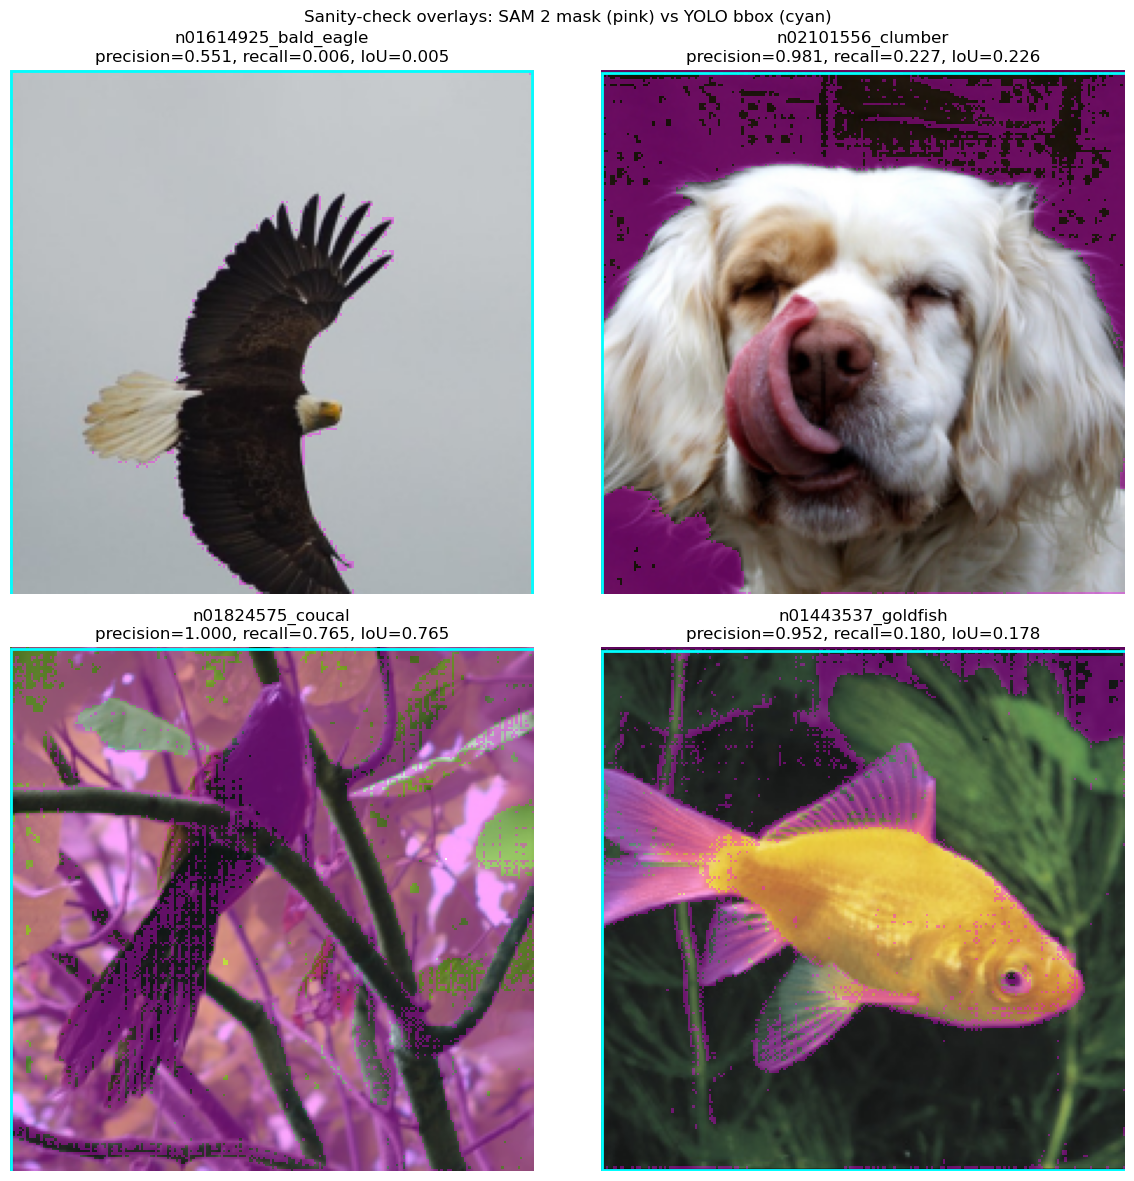

In [37]:
def select_overlay_examples(frame, desired=4):
    candidates = frame[frame["original_exists"]].copy()
    chosen = [
        candidates["box_recall"].idxmin(),
        candidates["box_precision"].idxmin(),
        (candidates["box_recall"] - candidates["box_recall"].median()).abs().idxmin(),
        candidates["box_recall"].idxmax(),
    ]
    chosen = list(dict.fromkeys(chosen))
    if len(chosen) < desired:
        filler = [idx for idx in candidates.index if idx not in chosen][: desired - len(chosen)]
        chosen.extend(filler)
    return candidates.loc[chosen[:desired]].copy()


overlay_examples = select_overlay_examples(metrics_df)
display(
    overlay_examples[["image", "bbox", "sam_score", "box_precision", "box_recall", "box_iou"]]
    .round(4)
    .reset_index(drop=True)
)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.ravel()

for ax, row in zip(axes, overlay_examples.itertuples(index=False)):
    image = plt.imread(row.original_path)
    mask = load_binary_mask(row.mask_path)
    x1, y1, x2, y2 = row.bbox

    ax.imshow(image)
    ax.imshow(np.ma.masked_where(~mask, mask), cmap="spring", alpha=0.35, interpolation="none")
    ax.add_patch(
        Rectangle(
            (x1, y1),
            x2 - x1 + 1,
            y2 - y1 + 1,
            fill=False,
            edgecolor="cyan",
            linewidth=2,
        )
    )
    ax.set_title(
        f"{row.image}\n"
        f"precision={row.box_precision:.3f}, recall={row.box_recall:.3f}, IoU={row.box_iou:.3f}"
    )
    ax.axis("off")

for ax in axes[len(overlay_examples) :]:
    ax.axis("off")

plt.suptitle("Sanity-check overlays: SAM 2 mask (pink) vs YOLO bbox (cyan)", y=0.98)
plt.tight_layout()
plt.show()


Using Matplotlib mathtext for reliable notebook rendering.


excess data in 'kern' subtable: 6 bytes


Saved ECDF plot to /Users/zd3504phd/Desktop/XAIV/analysis/figures/imagenet_box_mask_alignment_ecdf.pdf
Saved ECDF plot to /Users/zd3504phd/Desktop/XAIV/analysis/figures/imagenet_box_mask_alignment_ecdf.png


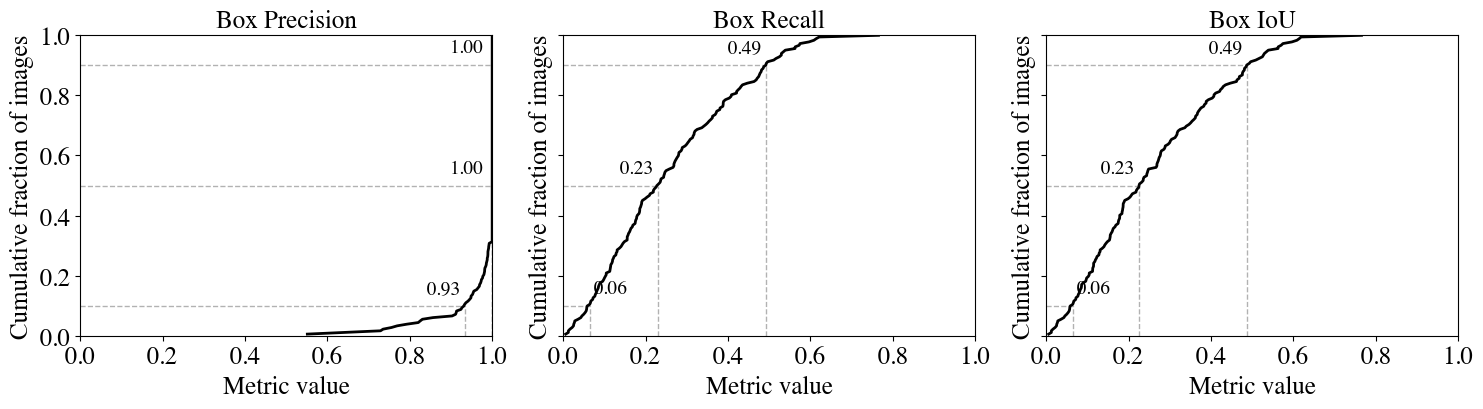

In [ ]:
def ecdf(values):
    xs = np.sort(np.asarray(values, dtype=float))
    ys = np.arange(1, len(xs) + 1) / len(xs)
    return xs, ys


plot_rc = {
    "font.family": "serif",
    "font.serif": ["Times", "DejaVu Serif"],
    "axes.labelsize": 14,
    "axes.titlesize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "text.usetex": False,
    "mathtext.fontset": "cm",
}

print("Using Matplotlib mathtext for reliable notebook rendering.")

label_fs = 18
tick_fs = 18
annot_fs = 14

metric_specs = [
    ("box_precision", "Box Precision"),
    ("box_recall", "Box Recall"),
    ("box_iou", "Box IoU"),
]


def plot_metric_ecdf(ax, values, title):
    xs, ys = ecdf(values)
    ax.plot(xs, ys, linewidth=2.0, color="black")

    qs = [0.10, 0.50, 0.90]
    qvals = np.quantile(values, qs)
    for q, v in zip(qs, qvals):
        ax.hlines(
            y=q,
            xmin=0.0,
            xmax=v,
            linestyle="--",
            linewidth=1.0,
            alpha=0.3,
            color="black",
        )
        ax.vlines(
            x=v,
            ymin=0.0,
            ymax=q,
            linestyle="--",
            linewidth=1.0,
            alpha=0.3,
            color="black",
        )

        x_text = max(min(v - 0.01, 0.98), 0.08)
        ha = "right" if v > 0.15 else "left"
        if ha == "left":
            x_text = min(v + 0.01, 0.98)
        ax.text(x_text, min(q + 0.03, 0.98), f"{v:.2f}", fontsize=annot_fs, ha=ha, va="bottom")

    ax.set_title(title, fontsize=label_fs)
    ax.set_xlabel("Metric value", fontsize=label_fs)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.0)
    ax.set_yticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    ax.tick_params(axis="both", labelsize=tick_fs)
    ax.spines["top"].set_visible(True)
    ax.spines["right"].set_visible(True)


with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharex=False, sharey=True)
    pdf_path = FIGURE_DIR / "imagenet_box_mask_alignment_ecdf.pdf"

    for ax, (column, title) in zip(axes, metric_specs):
        plot_metric_ecdf(ax, metrics_df[column].to_numpy(), title)
        ax.set_ylabel("Cumulative fraction of images", fontsize=label_fs)

    fig.tight_layout()
    fig.savefig(pdf_path, bbox_inches="tight")
    print(f"Saved ECDF plot to {pdf_path}")
    plt.show()
